# Эксперимент 8: Ансамбль Эксп.5 + Эксп.7

**Идея:** Две модели имеют взаимодополняющие сильные стороны:

| Модель | Кл.1 | Кл.2 | Кл.3 | Кл.4 | mIoU |
|--------|------|------|------|------|------|
| Эксп.5 (1 финальный слой) | 0.107 | 0.109 | 0.419 | 0.523 | 0.422 |
| Эксп.7 (4 слоя / DPT)    | 0.272 | 0.326 | 0.347 | 0.445 | 0.467 |

**Метод:** усредняем логиты (soft voting) обеих моделей перед argmax.
Обучение не требуется — только инференс сохранённых моделей.

Также пробуем взвешенный ансамбль: `α·Exp5 + (1-α)·Exp7` для разных α.

> **v2** — исправлен баг: `JointTransform` применяет flip и crop **одновременно** к изображению и маске.

## 1. Импорты и конфигурация

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.model_selection import train_test_split
import random, sys

print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'

IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5
BATCH_SIZE  = 4
TEST_SIZE   = 0.2
INTERMEDIATE_LAYERS = [3, 5, 8, 11]

MODEL_EXP5 = os.path.join(save_dir, f'model_ar_{IMG_H}x{IMG_W}.pt')
MODEL_EXP7 = os.path.join(save_dir, 'model_dpt_4layers_v2.pt')
print(f'Эксп.5 веса: {os.path.exists(MODEL_EXP5)}')
print(f'Эксп.7 веса: {os.path.exists(MODEL_EXP7)}')

PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
Эксп.5 веса: True
Эксп.7 веса: True


## 2. Данные

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_label(img_id, df):
    rows = df[df['ImageId'] == img_id]
    cls  = rows['ClassId'].dropna().astype(int).unique().tolist()
    return cls[0] if cls else 0


dino_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, transform):
        self.ids=ids; self.img_dir=img_dir
        self.df=df; self.transform=transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t  = self.transform(img)
        mask_t = torch.from_numpy(mask).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, img_id


all_labels = [get_label(i, train_df) for i in labeled_ids]
_, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
test_ds  = SteelSegDataset(test_ids, TRAIN_IMG_DIR, train_df, dino_transform)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Тестовых изображений: {len(test_ids)}')

Тестовых изображений: 1334


## 3. Загрузка DINOv2

In [3]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE).eval()
for p in dinov2.parameters():
    p.requires_grad = False
print(f'DINOv2 загружен ({sum(p.numel() for p in dinov2.parameters())/1e6:.1f}М параметров)')

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 загружен (86.6М параметров)


## 4. Архитектуры обеих моделей

In [4]:
# ── Эксп.5: один финальный слой ─────────────────────────────────────────────
class SegHeadNonSquare(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W):
        super().__init__()
        self.patch_h = patch_h
        self.patch_w = patch_w
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 256, 1),
            nn.BatchNorm2d(256), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, num_classes, 1),
        )
    def forward(self, pt):
        B, N, C = pt.shape
        x = pt.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
        return self.decoder(x)


# ── Эксп.7: 4 промежуточных слоя (DPT) ───────────────────────────────────────
class SegHeadDPT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers
        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, 256, 1),
                nn.BatchNorm2d(256), nn.GELU(),
            ) for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1),
            nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)
    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
            maps.append(self.proj[i](x))
        x = torch.cat(maps, dim=1)
        x = self.fuse(x)
        x = self.up1(x)
        x = self.up2(x)
        return self.head(x)


print('Архитектуры определены.')

Архитектуры определены.


## 5. Загрузка сохранённых весов

In [5]:
head5 = SegHeadNonSquare().to(DEVICE).eval()
head5.load_state_dict(torch.load(MODEL_EXP5, map_location=DEVICE))
print(f'Эксп.5 загружен: {sum(p.numel() for p in head5.parameters()):,} параметров')

head7 = SegHeadDPT().to(DEVICE).eval()
head7.load_state_dict(torch.load(MODEL_EXP7, map_location=DEVICE))
print(f'Эксп.7 загружен: {sum(p.numel() for p in head7.parameters()):,} параметров')

Эксп.5 загружен: 566,917 параметров
Эксп.7 загружен: 2,845,381 параметров


## 6. Оценка: одиночные модели и ансамбль

In [6]:
def evaluate(dl, alpha=0.5):
    """
    alpha: вес Эксп.5 в ансамбле (1-alpha — вес Эксп.7).
    alpha=1.0 → только Эксп.5
    alpha=0.0 → только Эксп.7
    alpha=0.5 → равный ансамбль
    """
    iou = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                       average='none').to(DEVICE)
    iou.reset()
    with torch.no_grad():
        for imgs, masks, _ in dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            # Эксп.5: финальный слой
            pt5   = dinov2.forward_features(imgs)['x_norm_patchtokens']
            lg5   = head5(pt5)

            # Эксп.7: 4 промежуточных слоя
            feats = dinov2.get_intermediate_layers(
                imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
            lg7   = head7(feats)

            # Мягкий ансамбль: взвешенная сумма логитов
            lg_ens = alpha * lg5 + (1 - alpha) * lg7

            iou.update(lg_ens.argmax(1), masks)
    return iou.compute().cpu().numpy()


print('Функция оценки определена.')
print('Запускаем оценку (это займёт несколько минут)...')

ipc5   = evaluate(test_dl, alpha=1.0)  # только Эксп.5
ipc7   = evaluate(test_dl, alpha=0.0)  # только Эксп.7
ipc_ens = evaluate(test_dl, alpha=0.5) # равный ансамбль

print('\nГотово!')

Функция оценки определена.
Запускаем оценку (это займёт несколько минут)...

Готово!


## 7. Поиск оптимального веса ансамбля

Перебираем α от 0 до 1 и смотрим, при каком значении mIoU максимален.

In [7]:
alphas = np.arange(0.0, 1.05, 0.1)
miou_by_alpha = []

for a in alphas:
    ipc = evaluate(test_dl, alpha=a)
    miou_by_alpha.append(float(ipc.mean()))
    print(f'  α={a:.1f} (Эксп5={a:.0%}, Эксп7={(1-a):.0%}): mIoU={ipc.mean():.4f}')

best_alpha = alphas[int(np.argmax(miou_by_alpha))]
best_miou  = max(miou_by_alpha)
print(f'\nЛучший α = {best_alpha:.1f}  →  mIoU = {best_miou:.4f}')

  α=0.0 (Эксп5=0%, Эксп7=100%): mIoU=0.5247
  α=0.1 (Эксп5=10%, Эксп7=90%): mIoU=0.5301
  α=0.2 (Эксп5=20%, Эксп7=80%): mIoU=0.5328
  α=0.3 (Эксп5=30%, Эксп7=70%): mIoU=0.5317
  α=0.4 (Эксп5=40%, Эксп7=60%): mIoU=0.5261
  α=0.5 (Эксп5=50%, Эксп7=50%): mIoU=0.5185
  α=0.6 (Эксп5=60%, Эксп7=40%): mIoU=0.5072
  α=0.7 (Эксп5=70%, Эксп7=30%): mIoU=0.4922
  α=0.8 (Эксп5=80%, Эксп7=20%): mIoU=0.4745
  α=0.9 (Эксп5=90%, Эксп7=10%): mIoU=0.4517
  α=1.0 (Эксп5=100%, Эксп7=0%): mIoU=0.4083

Лучший α = 0.2  →  mIoU = 0.5328


## 8. Итоговое сравнение

ИТОГОВОЕ СРАВНЕНИЕ:
  Эксп.5  (1 слой):              mIoU = 0.4083
  Эксп.7  (4 слоя DPT):          mIoU = 0.5247
  Ансамбль α=0.5 (50/50):        mIoU = 0.5185
  Ансамбль α=0.2 (оптим.):    mIoU = 0.5328

  Класс            Эксп.5     Эксп.7   Ансамбль
  ------------------------------------------------
  Фон              0.9449     0.9598     0.9615
  Дефект 1         0.2087     0.2723     0.2940
  Дефект 2         0.2461     0.3233     0.3417
  Дефект 3         0.3195     0.4928     0.4913
  Дефект 4         0.3226     0.5755     0.5756


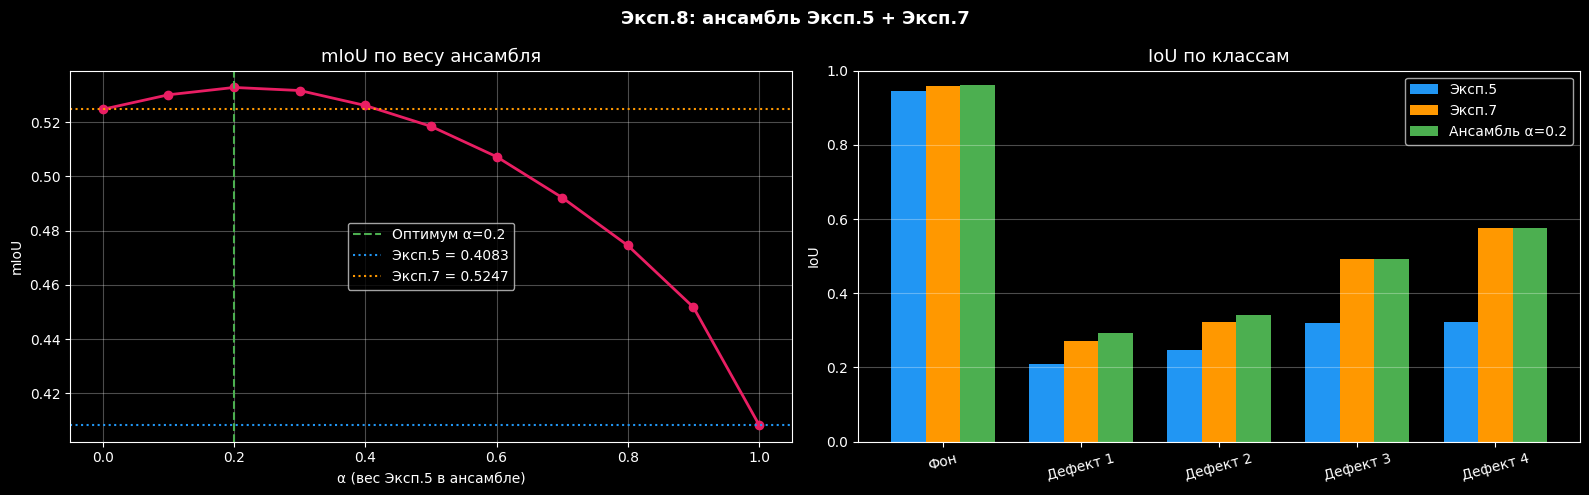

In [8]:
# Оцениваем с лучшим alpha
ipc_best = evaluate(test_dl, alpha=best_alpha)

names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']

print('ИТОГОВОЕ СРАВНЕНИЕ:')
print(f'  Эксп.5  (1 слой):              mIoU = {ipc5.mean():.4f}')
print(f'  Эксп.7  (4 слоя DPT):          mIoU = {ipc7.mean():.4f}')
print(f'  Ансамбль α=0.5 (50/50):        mIoU = {ipc_ens.mean():.4f}')
print(f'  Ансамбль α={best_alpha:.1f} (оптим.):    mIoU = {ipc_best.mean():.4f}')

print(f'\n  {"Класс":<12} {"Эксп.5":>10} {"Эксп.7":>10} {"Ансамбль":>10}')
print('  ' + '-'*48)
for c, (v5, v7, vb) in enumerate(zip(ipc5, ipc7, ipc_best)):
    print(f'  {names[c]:<12} {v5:>10.4f} {v7:>10.4f} {vb:>10.4f}')

# ── Графики ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Левый: mIoU по alpha
axes[0].plot(alphas, miou_by_alpha, 'o-', color='#E91E63', lw=2, ms=6)
axes[0].axvline(best_alpha, color='#4CAF50', ls='--', lw=1.5,
               label=f'Оптимум α={best_alpha:.1f}')
axes[0].axhline(ipc5.mean(), color='#2196F3', ls=':', lw=1.5,
               label=f'Эксп.5 = {ipc5.mean():.4f}')
axes[0].axhline(ipc7.mean(), color='#FF9800', ls=':', lw=1.5,
               label=f'Эксп.7 = {ipc7.mean():.4f}')
axes[0].set_xlabel('α (вес Эксп.5 в ансамбле)')
axes[0].set_ylabel('mIoU')
axes[0].set_title('mIoU по весу ансамбля', fontsize=13)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Правый: IoU по классам
x  = np.arange(NUM_CLASSES)
w  = 0.25
axes[1].bar(x - w,   ipc5,     w, label='Эксп.5', color='#2196F3')
axes[1].bar(x,       ipc7,     w, label='Эксп.7', color='#FF9800')
axes[1].bar(x + w,   ipc_best, w, label=f'Ансамбль α={best_alpha:.1f}', color='#4CAF50')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
axes[1].set_ylabel('IoU'); axes[1].set_ylim(0, 1)
axes[1].set_title('IoU по классам', fontsize=13)
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Эксп.8: ансамбль Эксп.5 + Эксп.7', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Сохранение

In [9]:
history_ens = {
    'best_alpha':      float(best_alpha),
    'miou_by_alpha':   miou_by_alpha,
    'alphas':          alphas.tolist(),
    'iou_exp5':        ipc5.tolist(),
    'iou_exp7':        ipc7.tolist(),
    'iou_ensemble_50': ipc_ens.tolist(),
    'iou_ensemble_best': ipc_best.tolist(),
    'miou_exp5':       float(ipc5.mean()),
    'miou_exp7':       float(ipc7.mean()),
    'miou_ensemble_50': float(ipc_ens.mean()),
    'miou_ensemble_best': float(ipc_best.mean()),
}
with open(os.path.join(save_dir, 'history_ensemble_v2.json'), 'w') as f:
    json.dump(history_ens, f, indent=2)
print(f'Результаты сохранены: history_ensemble.json')
print(f'\nИтог: mIoU {ipc5.mean():.4f} (Эксп.5) + {ipc7.mean():.4f} (Эксп.7) '
      f'→ {ipc_best.mean():.4f} (ансамбль α={best_alpha:.1f})')

Результаты сохранены: history_ensemble.json

Итог: mIoU 0.4083 (Эксп.5) + 0.5247 (Эксп.7) → 0.5328 (ансамбль α=0.2)
